**01_data_preprocessing**

In [ ]:
# 1. Data Cleaning
# 2. Check Missing Values
# 3. Target Variable Encoding
# 4. Categorical Encoding
# Binary Features → Label Encoding
# Multi-Class Features → One-Hot Encoding
# 5. Feature Scaling - Apply scaling for:Logistic Regression,SVM

In [1]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2. Import Libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
# 3. Load Dataset from Drive
file_path = "/content/drive/MyDrive/ML-Assignment/raw/Raw_Employee-Attrition.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")
df.head()

Dataset Loaded Successfully ✅


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
#4. Initial Exploration
print("\nShape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())


Shape: (1470, 35)

Missing Values:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
Yea

In [5]:
# 5. Drop Irrelevant Columns
drop_cols = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
df.drop(columns=drop_cols, inplace=True)

print("\nColumns after dropping unnecessary features:")
print(df.columns)


Columns after dropping unnecessary features:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [6]:
# 6. Encode Target Variable\
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

In [7]:
# 7. Encode Binary Categorical Columns
binary_cols = ['Gender', 'OverTime']

le = LabelEncoder()
for col in binary_cols:
  df[col] = le.fit_transform(df[col])

In [8]:
# 8. One-Hot Encoding for Multi-Class Features
multi_cols = [
'BusinessTravel', 'Department', 'EducationField',
'JobRole', 'MaritalStatus'
]

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("\nAfter Encoding:")
print(df.head())


After Encoding:
   Age  Attrition  DailyRate  DistanceFromHome  Education  \
0   41          1       1102                 1          2   
1   49          0        279                 8          1   
2   37          1       1373                 2          2   
3   33          0       1392                 3          4   
4   27          0        591                 2          1   

   EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel  ...  \
0                        2       0          94               3         2  ...   
1                        3       1          61               2         2  ...   
2                        4       1          92               2         1  ...   
3                        4       0          56               3         1  ...   
4                        1       1          40               3         1  ...   

   JobRole_Human Resources  JobRole_Laboratory Technician  JobRole_Manager  \
0                    False                         

In [9]:
# 9. Split Features and Target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [10]:
# 10. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [12]:
# 11. Combine Scaled Features with Target
processed_df = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

print("\nProcessed Dataset Shape:", processed_df.shape)


Processed Dataset Shape: (1470, 45)


In [16]:
# 12. Save Processed Data to Drive
save_path = "/content/drive/MyDrive/ML-Assignment/processed/processed_dataset.csv"

processed_df.to_csv(save_path, index=False)

print(f"\n✅ Processed dataset saved successfully at:\n{save_path}")


✅ Processed dataset saved successfully at:
/content/drive/MyDrive/ML-Assignment/processed/processed_dataset.csv


2. Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = processed_df.drop("Attrition", axis=1)
y = processed_df["Attrition"]

# Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1176, 44)
Test shape: (294, 44)


In [ ]:
# stratify=y keeps class balance consistent

3. Handle Class Imbalance (SMOTE)

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_smote.value_counts())

Before SMOTE: Attrition
0    986
1    190
Name: count, dtype: int64
After SMOTE: Attrition
0    986
1    986
Name: count, dtype: int64


In [ ]:
# Only apply SMOTE on training data

4. Feature Selection / Analysis

In [ ]:
# Method 1: Correlation


Top Correlated Features:

Attrition                           1.000000
OverTime                            0.287181
MaritalStatus_Single                0.249091
JobRole_Laboratory Technician       0.195368
JobRole_Sales Representative        0.178014
BusinessTravel_Travel_Frequently    0.123878
DistanceFromHome                    0.110300
Department_Sales                    0.098694
NumCompaniesWorked                  0.063571
EducationField_Marketing            0.057729
Name: Attrition, dtype: float64

Least Correlated Features:

JobInvolvement              -0.157884
JobRole_Research Director   -0.165340
StockOptionLevel            -0.228841
MonthlyIncome               -0.269029
JobLevel                    -0.274567
YearsAtCompany              -0.275323
YearsInCurrentRole          -0.282775
Age                         -0.282875
YearsWithCurrManager        -0.298768
TotalWorkingYears           -0.305585
Name: Attrition, dtype: float64


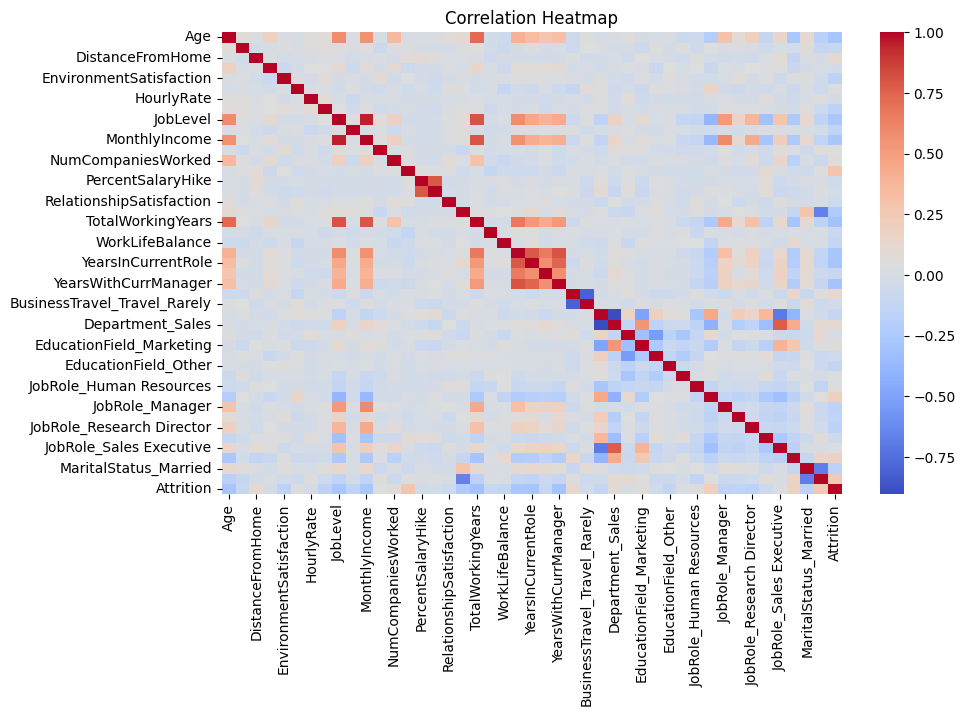

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine X and y for correlation
train_df = X_train_smote.copy()
train_df["Attrition"] = y_train_smote

# Correlation with target
corr = train_df.corr()["Attrition"].sort_values(ascending=False)

print("\nTop Correlated Features:\n")
print(corr.head(10))

print("\nLeast Correlated Features:\n")
print(corr.tail(10))

# Optional Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(train_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Method 2: Feature Importance (Random Forest)


Top Important Features:

                 Feature  Importance
13              OverTime    0.096049
24  YearsWithCurrManager    0.057314
17      StockOptionLevel    0.054179
10         MonthlyIncome    0.045465
21        YearsAtCompany    0.043443
9        JobSatisfaction    0.041978
8               JobLevel    0.041868
18     TotalWorkingYears    0.039607
0                    Age    0.038788
12    NumCompaniesWorked    0.037127


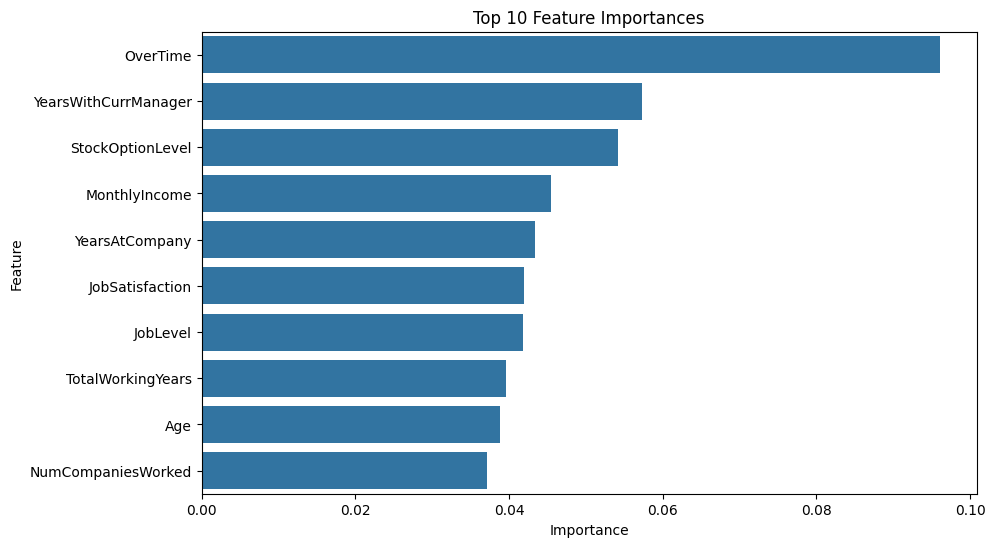

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features:\n")
print(feature_importance_df.head(10))

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df.head(10))
plt.title("Top 10 Feature Importances")
plt.show()

**5. Train Models**

(4 Algorithms)

Logistic Regression

Decision Tree

Random Forest

SVM

In [ ]:
# Import Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Initialize Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
     "Decision Tree": DecisionTreeClassifier(random_state=42),
     "Random Forest": RandomForestClassifier(random_state=42)
}

In [ ]:
# Train Models
trained_models = {}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    trained_models[name] = model
    print(f"{name} trained successfully")

In [ ]:
# 8. Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt



# Store results

results = []



# Loop through models

for name, model in models.items():
    
    # Train model

    model.fit(X_train, y_train)
    
    # Predictions

    y_pred = model.predict(X_test)
    
    # Metrics

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred, average='weighted')

    recall = recall_score(y_test, y_pred, average='weighted')

    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Save results

    results.append([name, accuracy, precision, recall, f1])
    
    # Confusion Matrix

    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'Confusion Matrix - {name}')

    plt.xlabel('Predicted')

    plt.ylabel('Actual')

    plt.show()
    
    # Classification Report

    print(f"\n{name} Classification Report:\n")

    print(classification_report(y_test, y_pred))



# Comparison Table

results_df = pd.DataFrame(results, columns=[

    "Model", "Accuracy", "Precision", "Recall", "F1 Score"

])



print("\n🔹 Model Comparison Table")

display(results_df)



# Sort by Accuracy

results_df = results_df.sort_values(by="Accuracy", ascending=False)

results_df

In [ ]:
# Best Model Selection

In [ ]:
# 9. ROC Curve + AUC

In [ ]:
# 10. Cross Validation
from sklearn.model_selection import cross_val_score
import numpy as np

cv_results = []

for name, model in models.items():
    
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    
    cv_results.append([
        name,
        scores.mean(),
        scores.std()
    ])

cv_df = pd.DataFrame(cv_results, columns=[
    "Model", "CV Mean Accuracy", "CV Std"
])

print("\n🔹 Cross Validation Results")
display(cv_df)

In [ ]:
# 11. Model Saving
import joblib

# Train all models and store accuracy
best_accuracy = 0
best_model = None
best_model_name = ""

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

# Save best model
joblib.dump(best_model, "best_model.pkl")

print(f"✅ Best Model Saved: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")

In [ ]:
# Load saved model

loaded_model = joblib.load("best_model.pkl")



# Predict

y_pred = loaded_model.predict(X_test)